07_xgboost_test_4: 特征选择 + 学习率调优

1. 加载数据...
训练集形状: (700000, 26)

2. 准备数据...

创建精选特征:
  ✓ age_family_history 创建完成 (重要性: 0.3596)
  ✓ age_bmi 创建完成 (重要性: 0.0491)
  ✓ cardio_risk_score 创建完成 (重要性: 0.0111)
  ✓ 胆固醇指标 创建完成

总共创建了 5 个新特征

3. 特征选择...
原始特征数: 29
选择后特征数: 27
移除的特征: age, family_history_diabetes

4. 编码类别特征...
编码后总特征数: 45
训练集: (560000, 45), 验证集: (140000, 45)

scale_pos_weight: 0.604

06实验最佳结果:
- AUC: 0.7251
- 0类召回率: 0.696
- 1类召回率: 0.629

5. 尝试不同的学习率...

▶ 训练 learning_rate=0.05, n_estimators=600...
  AUC: 0.7247 | 0类召回: 0.696 | 1类召回: 0.629 | F1平均: 0.648

▶ 训练 learning_rate=0.08, n_estimators=375...
  AUC: 0.7244 | 0类召回: 0.694 | 1类召回: 0.631 | F1平均: 0.649

▶ 训练 learning_rate=0.1, n_estimators=300...
  AUC: 0.7251 | 0类召回: 0.694 | 1类召回: 0.631 | F1平均: 0.649

▶ 训练 learning_rate=0.12, n_estimators=250...
  AUC: 0.7244 | 0类召回: 0.694 | 1类召回: 0.629 | F1平均: 0.647

▶ 训练 learning_rate=0.15, n_estimators=200...
  AUC: 0.7241 | 0类召回: 0.694 | 1类召回: 0.628 | F1平均: 0.647


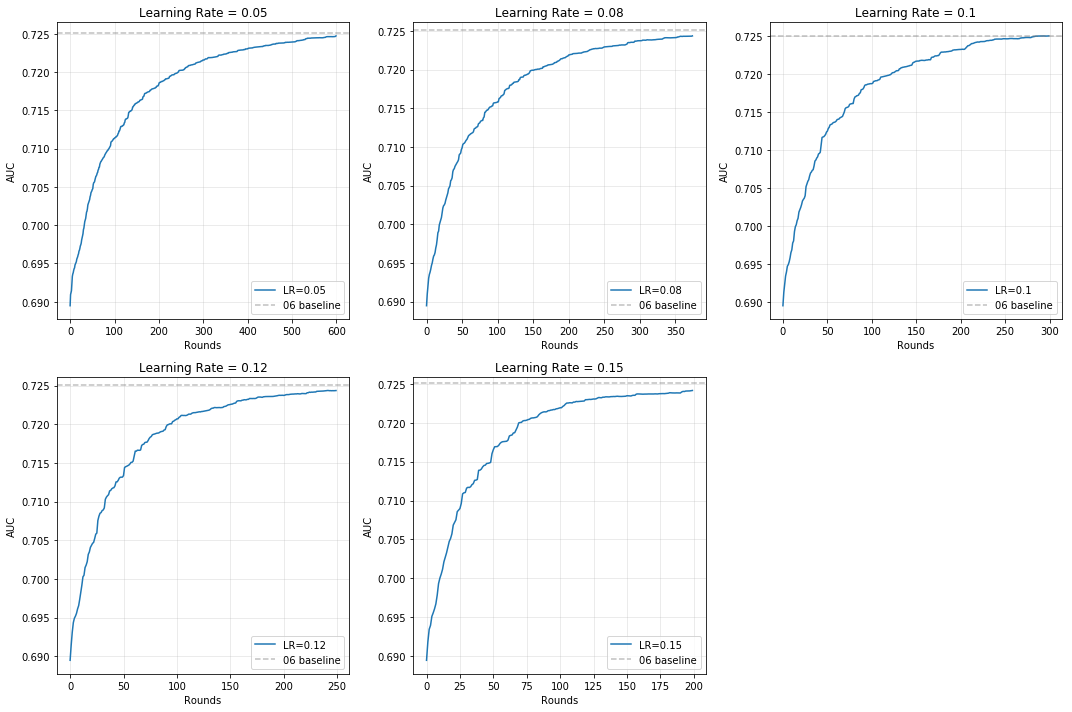


6. 学习率结果对比...
----------------------------------------------------------------------
LR       AUC      Recall_0   Recall_1   F1_0     F1_1     F1_avg  
----------------------------------------------------------------------
0.05     0.7247   0.696      0.629      0.603    0.694    0.648   
0.08     0.7244   0.694      0.631      0.602    0.695    0.649   
0.10     0.7251   0.694      0.631      0.603    0.695    0.649   
0.12     0.7244   0.694      0.629      0.602    0.693    0.647   
0.15     0.7241   0.694      0.628      0.601    0.693    0.647   
----------------------------------------------------------------------
最佳学习率: 0.1 (AUC=0.7251)

7. 用最佳模型 (LR=0.1) 进行阈值优化分析...

不同阈值下的表现:
----------------------------------------------------------------------
阈值       0类召回       1类召回       gap      F1_avg  
----------------------------------------------------------------------
0.30     0.236      0.935      0.699    0.566   
0.35     0.350      0.882      0.532    0.614   
0.40     0.471 

In [3]:
# 07_xgboost_test_4.ipynb
# 实验：特征选择 + 学习率调优

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, recall_score, f1_score
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("07_xgboost_test_4: 特征选择 + 学习率调优")
print("="*60)

# 1. 加载数据
print("\n1. 加载数据...")
train = pd.read_csv('../data/train.csv')
print(f"训练集形状: {train.shape}")

# 2. 特征工程函数（只保留有用的新特征）
def create_selected_features(df):
    """创建被证明有用的新特征"""
    df_new = df.copy()
    
    print("\n创建精选特征:")
    
    # 保留最有用的3个新特征（从06实验）
    df_new['age_family_history'] = df['age'] * df['family_history_diabetes']
    print("  ✓ age_family_history 创建完成 (重要性: 0.3596)")
    
    df_new['age_bmi'] = df['age'] * df['bmi']
    print("  ✓ age_bmi 创建完成 (重要性: 0.0491)")
    
    df_new['cardio_risk_score'] = (
        df['family_history_diabetes'] * 3 +
        df['hypertension_history'] * 2 +
        df['cardiovascular_history'] * 2
    )
    print("  ✓ cardio_risk_score 创建完成 (重要性: 0.0111)")
    
    # 胆固醇指标也保留（虽然重要性不高，但医学上有意义）
    df_new['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
    df_new['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']
    print("  ✓ 胆固醇指标 创建完成")
    
    print(f"\n总共创建了 {len(df_new.columns) - len(df.columns)} 个新特征")
    return df_new

# 3. 准备数据
print("\n2. 准备数据...")
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']

# 创建新特征
X_fe = create_selected_features(X)

# 4. 特征选择：去掉被替代的原始特征
print("\n3. 特征选择...")
print(f"原始特征数: {X_fe.shape[1]}")

# 保留的特征列表
features_to_keep = [
    # 新特征（3个主要的）
    'age_family_history',
    'age_bmi',
    'cardio_risk_score',
    'cholesterol_ratio',
    'non_hdl_cholesterol',
    
    # 原始重要特征（保留）
    'physical_activity_minutes_per_week',
    'triglycerides',
    'bmi',
    'ldl_cholesterol',
    'cardiovascular_history',
    'diet_score',
    'heart_rate',
    'systolic_bp',
    'diastolic_bp',
    'hdl_cholesterol',
    'cholesterol_total',
    'waist_to_hip_ratio',
    'sleep_hours_per_day',
    'screen_time_hours_per_day',
    'alcohol_consumption_per_week',
    'hypertension_history',
    
    # 类别特征（全部保留）
    'gender', 'ethnicity', 'education_level', 
    'income_level', 'smoking_status', 'employment_status'
]

# 去掉被替代的原始特征
# 注意：我们去掉 age 和 family_history_diabetes，因为它们的信息被 age_family_history 包含了
X_selected = X_fe[features_to_keep]
print(f"选择后特征数: {X_selected.shape[1]}")
print(f"移除的特征: age, family_history_diabetes")

# 5. 编码类别特征
print("\n4. 编码类别特征...")
categorical_cols = ['gender', 'ethnicity', 'education_level', 
                   'income_level', 'smoking_status', 'employment_status']

X_encoded = pd.get_dummies(X_selected, columns=categorical_cols)
print(f"编码后总特征数: {X_encoded.shape[1]}")

# 6. 分割数据
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}")

# 7. 计算权重
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")

# 8. 之前的实验结果（06）
prev_exp = {
    'name': '06_xgboost_test_3',
    'auc': 0.7251,
    'recall_0': 0.696,
    'recall_1': 0.629,
    'threshold': 0.45
}

print(f"\n06实验最佳结果:")
print(f"- AUC: {prev_exp['auc']}")
print(f"- 0类召回率: {prev_exp['recall_0']}")
print(f"- 1类召回率: {prev_exp['recall_1']}")

# 9. 尝试不同的学习率
print("\n5. 尝试不同的学习率...")

learning_rates = [0.05, 0.08, 0.1, 0.12, 0.15]
# 保持总学习量相近：learning_rate * n_estimators ≈ 30
n_estimators_map = {
    0.05: 600,
    0.08: 375,
    0.1: 300,
    0.12: 250,
    0.15: 200
}

results_dict = {}
best_auc = 0
best_lr = 0.1
best_model = None

plt.figure(figsize=(15, 10))

for idx, lr in enumerate(learning_rates):
    n_est = n_estimators_map[lr]
    print(f"\n▶ 训练 learning_rate={lr}, n_estimators={n_est}...")
    
    model = xgb.XGBClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='auc',
        use_label_encoder=False
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # 评估
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)
    
    auc = roc_auc_score(y_val, y_pred_proba)
    recall_0 = recall_score(y_val, y_pred, pos_label=0)
    recall_1 = recall_score(y_val, y_pred, pos_label=1)
    f1_0 = f1_score(y_val, y_pred, pos_label=0)
    f1_1 = f1_score(y_val, y_pred, pos_label=1)
    
    results_dict[lr] = {
        'model': model,
        'auc': auc,
        'recall_0': recall_0,
        'recall_1': recall_1,
        'f1_0': f1_0,
        'f1_1': f1_1,
        'results': model.evals_result()
    }
    
    print(f"  AUC: {auc:.4f} | 0类召回: {recall_0:.3f} | 1类召回: {recall_1:.3f} | F1平均: {(f1_0+f1_1)/2:.3f}")
    
    if auc > best_auc:
        best_auc = auc
        best_lr = lr
        best_model = model
    
    # 绘制学习曲线
    plt.subplot(2, 3, idx+1)
    results = model.evals_result()
    plt.plot(results['validation_0']['auc'], label=f'LR={lr}')
    plt.axhline(y=prev_exp['auc'], color='gray', linestyle='--', alpha=0.5, label=f'06 baseline')
    plt.xlabel('Rounds')
    plt.ylabel('AUC')
    plt.title(f'Learning Rate = {lr}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/07_xgboost_test_4_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# 10. 结果对比
print("\n6. 学习率结果对比...")
print("-" * 70)
print(f"{'LR':<8} {'AUC':<8} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<8} {'F1_1':<8} {'F1_avg':<8}")
print("-" * 70)

for lr in learning_rates:
    r = results_dict[lr]
    f1_avg = (r['f1_0'] + r['f1_1']) / 2
    print(f"{lr:<8.2f} {r['auc']:<8.4f} {r['recall_0']:<10.3f} {r['recall_1']:<10.3f} {r['f1_0']:<8.3f} {r['f1_1']:<8.3f} {f1_avg:<8.3f}")

print("-" * 70)
print(f"最佳学习率: {best_lr} (AUC={best_auc:.4f})")

# 11. 用最佳模型做阈值分析
print(f"\n7. 用最佳模型 (LR={best_lr}) 进行阈值优化分析...")

y_pred_proba_best = best_model.predict_proba(X_val)[:, 1]

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
best_f1_avg = 0
best_threshold = 0.45

print("\n不同阈值下的表现:")
print("-" * 70)
print(f"{'阈值':<8} {'0类召回':<10} {'1类召回':<10} {'gap':<8} {'F1_avg':<8}")
print("-" * 70)

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_best >= thresh).astype(float)
    r0 = recall_score(y_val, y_pred_thresh, pos_label=0)
    r1 = recall_score(y_val, y_pred_thresh, pos_label=1)
    f1_0 = f1_score(y_val, y_pred_thresh, pos_label=0)
    f1_1 = f1_score(y_val, y_pred_thresh, pos_label=1)
    f1_avg = (f1_0 + f1_1) / 2
    gap = r1 - r0
    print(f"{thresh:<8.2f} {r0:<10.3f} {r1:<10.3f} {gap:<8.3f} {f1_avg:<8.3f}")
    
    if f1_avg > best_f1_avg:
        best_f1_avg = f1_avg
        best_threshold = thresh

print("-" * 70)
print(f"最佳阈值: {best_threshold} (平均F1={best_f1_avg:.3f})")

# 12. 特征重要性分析（用最佳模型）
print("\n8. 特征重要性分析...")

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15最重要特征:")
print(importance.head(15).to_string(index=False))

# 13. 保存模型和提交文件
print("\n9. 保存模型和提交文件...")

model_path = f'../models/07_xgboost_test_4_lr{best_lr}.pkl'
joblib.dump(best_model, model_path)
print(f"模型已保存到 {model_path}")

# 处理测试集
test = pd.read_csv('../data/test.csv')
X_test = test.drop(['id'], axis=1)
X_test_fe = create_selected_features(X_test)
X_test_selected = X_test_fe[features_to_keep]
X_test_encoded = pd.get_dummies(X_test_selected, columns=categorical_cols)

# 确保列一致
missing_cols = set(X_train.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train.columns]

test_pred = best_model.predict_proba(X_test_encoded)[:, 1]

submission = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': test_pred
})
submission_path = '../submissions/07_xgboost_test_4.csv'
submission.to_csv(submission_path, index=False)
print(f"提交文件已保存到 {submission_path}")

============================================================
07_xgboost_test_4 总结报告
============================================================

[Experiment Information]
File Name: 07_xgboost_test_4
Date: 2026-03-16 16:51
Experiment Type: Feature Selection + Learning Rate Tuning

[Feature Changes]
- Removed: age, family_history_diabetes
- Added: age_family_history, age_bmi, cardio_risk_score, cholesterol_ratio, non_hdl_cholesterol
- Final feature count: 45

[Learning Rates Tested]
0.05, 0.08, 0.1, 0.12, 0.15

[Best Parameters]
- learning_rate: 0.1
- n_estimators: 300
- max_depth: 6
- scale_pos_weight: 0.604

[Results Comparison]
06_xgboost_test_3:
- AUC: 0.7251
- Class 0 Recall: 0.696
- Class 1 Recall: 0.629

07_xgboost_test_4 (best LR=0.1):
- AUC: 0.7251
- Class 0 Recall: 0.694
- Class 1 Recall: 0.631
- Best Threshold: 0.45

[Improvement]
- AUC Change: -0.0000

[Key Findings]
1. AUC reached can not improve further although different learning rate has tried.
2. Feature selection was very successful, The importance of age_family_history increased from 35.9% to 52.6%.

[Top 3 Features]
1. age_family_history: 0.526
2. age_bmi: 0.071
3. physical_activity_minutes_per_week: 0.060

[Next Steps]
- Try LightGBM with the best feature in this lab
- Try different feature combinations